# QR_GEOM(geom, cell, dist=0.0, wkid=-1)

Clip a geometry based on its QR elements.

In [9]:
import geofunctions as S
import geopandas as gp
import pyspark.sql.functions as F

In [10]:
data = [("POLYGON((0 0,100 0,100 100,0 0))",)]

### Read the geometry in WKT and convert it to internal binary representation (WKB).

In [11]:
df = spark.createDataFrame(data, "wkt string").select(
    S.st_fromtext("wkt").alias("geometry")
)

### Plot the geometry.

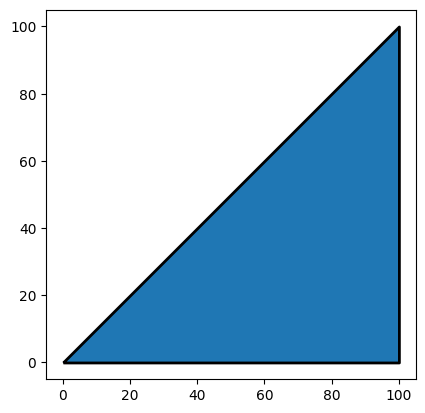

In [12]:
pdf = df.toPandas()
pdf.geometry = gp.GeoSeries.from_wkb(pdf.geometry)
gdf = gp.GeoDataFrame(pdf)
_ = gdf.plot(linewidth=2, edgecolor="black")

### Explode the clips of the geometry by its QR cell.

Note that here, the `dist` can be negative :-)

In [17]:
cell = 40.0
dist = -0.5

qr = df.select(S.qr_geom_explode(df.geometry, cell, dist))

In [18]:
qr.printSchema()

root
 |-- qr: struct (nullable = false)
 |    |-- qr: long (nullable = false)
 |    |-- geom: binary (nullable = false)



### Get the geometry.

In [19]:
pdf = qr.select(
    F.hex("qr.qr").alias("qr"), F.col("qr.geom").alias("geometry")
).toPandas()

### Plot the clipped geometries by QR.

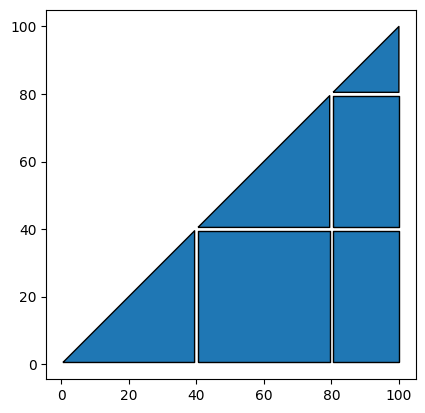

In [20]:
pdf.geometry = gp.GeoSeries.from_wkb(pdf.geometry)
gdf = gp.GeoDataFrame(pdf)
_ = gdf.plot(linewidth=1, edgecolor="black")